<a href="https://colab.research.google.com/github/vennelanalajam/myproject/blob/main/HeartDiseasePrediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Project Title : Heart Disease Prediction using Machine Learning



# Objective :      
The objective of this project is to build a machine learning model that can predict whether a patient has heart disease based on medical attributes.

# Problem Type :
- Supervised Learning
- Binary Classification (0 = No Disease, 1 = Disease)

# Step 1 : Problem Statement
 To build a machine learning model that can predict whether a patient has heart disease based on medical attributes.

# Step 2 : Import Libraries
Importing Required Libraries

In [1]:
# Basic Libraries
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# ML Tools
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Metrics
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score, roc_curve

# Step 3: Load Datasets

In [2]:
values = pd.read_csv("/content/values.csv")
labels = pd.read_csv("/content/labels.csv")

# merge datasets
df = values.merge(labels, on = "patient_id")
df.head()

,patient_id,slope_of_peak_exercise_st_segment,thal,resting_blood_pressure,chest_pain_type,num_major_vessels,fasting_blood_sugar_gt_120_mg_per_dl,resting_ekg_results,serum_cholesterol_mg_per_dl,oldpeak_eq_st_depression,sex,age,max_heart_rate_achieved,exercise_induced_angina,heart_disease_present
0,0z64un,1,normal,128,2,0,0,2,308,0.0,1,45,170,0,0
1,ryoo3j,2,normal,110,3,0,0,0,214,1.6,0,54,158,0,0
2,yt1s1x,1,normal,125,4,3,0,2,304,0.0,1,77,162,1,1
3,l2xjde,1,reversible_defect,152,4,0,0,0,223,0.0,1,40,181,0,1
4,oyt4ek,3,reversible_defect,178,1,0,0,2,270,4.2,1,59,145,0,0


# Step 4 : Data Understanding
# Basic steps

In [3]:
df.head()

,patient_id,slope_of_peak_exercise_st_segment,thal,resting_blood_pressure,chest_pain_type,num_major_vessels,fasting_blood_sugar_gt_120_mg_per_dl,resting_ekg_results,serum_cholesterol_mg_per_dl,oldpeak_eq_st_depression,sex,age,max_heart_rate_achieved,exercise_induced_angina,heart_disease_present
0,0z64un,1,normal,128,2,0,0,2,308,0.0,1,45,170,0,0
1,ryoo3j,2,normal,110,3,0,0,0,214,1.6,0,54,158,0,0
2,yt1s1x,1,normal,125,4,3,0,2,304,0.0,1,77,162,1,1
3,l2xjde,1,reversible_defect,152,4,0,0,0,223,0.0,1,40,181,0,1
4,oyt4ek,3,reversible_defect,178,1,0,0,2,270,4.2,1,59,145,0,0


In [4]:
df.tail()

,patient_id,slope_of_peak_exercise_st_segment,thal,resting_blood_pressure,chest_pain_type,num_major_vessels,fasting_blood_sugar_gt_120_mg_per_dl,resting_ekg_results,serum_cholesterol_mg_per_dl,oldpeak_eq_st_depression,sex,age,max_heart_rate_achieved,exercise_induced_angina,heart_disease_present
175,5qfar3,2,reversible_defect,125,4,2,1,0,254,0.2,1,67,163,0,1
176,2s2b1f,2,normal,180,4,0,0,1,327,3.4,0,55,117,1,1
177,nsd00i,2,reversible_defect,125,3,0,0,0,309,1.8,1,64,131,1,1
178,0xw93k,1,normal,124,3,2,1,0,255,0.0,1,48,175,0,0
179,2nx10r,1,normal,160,3,1,0,0,201,0.0,0,54,163,0,0


In [5]:
df.columns

Index(['patient_id', 'slope_of_peak_exercise_st_segment', 'thal',
       'resting_blood_pressure', 'chest_pain_type', 'num_major_vessels',
       'fasting_blood_sugar_gt_120_mg_per_dl', 'resting_ekg_results',
       'serum_cholesterol_mg_per_dl', 'oldpeak_eq_st_depression', 'sex', 'age',
       'max_heart_rate_achieved', 'exercise_induced_angina',
       'heart_disease_present'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180 entries, 0 to 179
Data columns (total 15 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   patient_id                            180 non-null    object 
 1   slope_of_peak_exercise_st_segment     180 non-null    int64  
 2   thal                                  180 non-null    object 
 3   resting_blood_pressure                180 non-null    int64  
 4   chest_pain_type                       180 non-null    int64  
 5   num_major_vessels                     180 non-null    int64  
 6   fasting_blood_sugar_gt_120_mg_per_dl  180 non-null    int64  
 7   resting_ekg_results                   180 non-null    int64  
 8   serum_cholesterol_mg_per_dl           180 non-null    int64  
 9   oldpeak_eq_st_depression              180 non-null    float64
 10  sex                                   180 non-null    int64  
 11  age                

In [7]:
df.dtypes

,0
patient_id,object
slope_of_peak_exercise_st_segment,int64
thal,object
resting_blood_pressure,int64
chest_pain_type,int64
num_major_vessels,int64
fasting_blood_sugar_gt_120_mg_per_dl,int64
resting_ekg_results,int64
serum_cholesterol_mg_per_dl,int64
oldpeak_eq_st_depression,float64


In [9]:
df.describe()

,slope_of_peak_exercise_st_segment,resting_blood_pressure,chest_pain_type,num_major_vessels,fasting_blood_sugar_gt_120_mg_per_dl,resting_ekg_results,serum_cholesterol_mg_per_dl,oldpeak_eq_st_depression,sex,age,max_heart_rate_achieved,exercise_induced_angina,heart_disease_present
count,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000
mean,1.550000,131.311111,3.155556,0.694444,0.161111,1.050000,249.211111,1.010000,0.688889,54.811111,149.483333,0.316667,0.444444
std,0.618838,17.010443,0.938454,0.969347,0.368659,0.998742,52.717969,1.121357,0.464239,9.334737,22.063513,0.466474,0.498290
min,1.000000,94.000000,1.000000,0.000000,0.000000,0.000000,126.000000,0.000000,0.000000,29.000000,96.000000,0.000000,0.000000
25%,1.000000,120.000000,3.000000,0.000000,0.000000,0.000000,213.750000,0.000000,0.000000,48.000000,132.000000,0.000000,0.000000
50%,1.000000,130.000000,3.000000,0.000000,0.000000,2.000000,245.500000,0.800000,1.000000,55.000000,152.000000,0.000000,0.000000
75%,2.000000,140.000000,4.000000,1.000000,0.000000,2.000000,281.250000,1.600000,1.000000,62.000000,166.250000,1.000000,1.000000
max,3.000000,180.000000,4.000000,3.000000,1.000000,2.000000,564.000000,6.200000,1.000000,77.000000,202.000000,1.000000,1.000000


In [10]:
df.isnull().sum()

,0
patient_id,0
slope_of_peak_exercise_st_segment,0
thal,0
resting_blood_pressure,0
chest_pain_type,0
num_major_vessels,0
fasting_blood_sugar_gt_120_mg_per_dl,0
resting_ekg_results,0
serum_cholesterol_mg_per_dl,0
oldpeak_eq_st_depression,0


In [11]:
df.duplicated().sum()

np.int64(0)

In [23]:
df.drop("patient_id" , axis = 1,inplace = True)

KeyError: "['patient_id'] not found in axis"

In [24]:
df.columns

Index(['slope_of_peak_exercise_st_segment', 'thal', 'resting_blood_pressure',
       'chest_pain_type', 'num_major_vessels',
       'fasting_blood_sugar_gt_120_mg_per_dl', 'resting_ekg_results',
       'serum_cholesterol_mg_per_dl', 'oldpeak_eq_st_depression', 'sex', 'age',
       'max_heart_rate_achieved', 'exercise_induced_angina',
       'heart_disease_present'],
      dtype='object')

In [28]:
df["thal"].value_counts()

,count
thal,
normal,98
reversible_defect,74
fixed_defect,8


In [29]:
df = pd.get_dummies(df, columns = ["thal"], drop_first = True)

In [33]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180 entries, 0 to 179
Data columns (total 15 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   slope_of_peak_exercise_st_segment     180 non-null    int64  
 1   resting_blood_pressure                180 non-null    int64  
 2   chest_pain_type                       180 non-null    int64  
 3   num_major_vessels                     180 non-null    int64  
 4   fasting_blood_sugar_gt_120_mg_per_dl  180 non-null    int64  
 5   resting_ekg_results                   180 non-null    int64  
 6   serum_cholesterol_mg_per_dl           180 non-null    int64  
 7   oldpeak_eq_st_depression              180 non-null    float64
 8   sex                                   180 non-null    int64  
 9   age                                   180 non-null    int64  
 10  max_heart_rate_achieved               180 non-null    int64  
 11  exercise_induced_an

# In this  data no required  to do Handling missing values step.

# Step 5: Exploratory Data Analysis

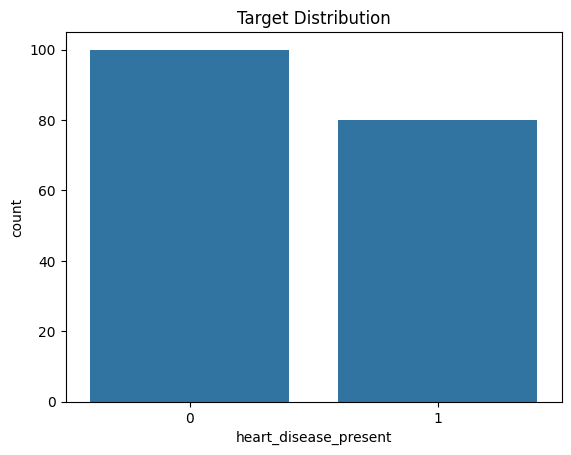

In [25]:
# Target Distribution
sns.countplot(x = df["heart_disease_present"] ,data = df)
plt.title("Target Distribution")
plt.show()

In [26]:
df["heart_disease_present"].value_counts()

,count
heart_disease_present,
0,100
1,80


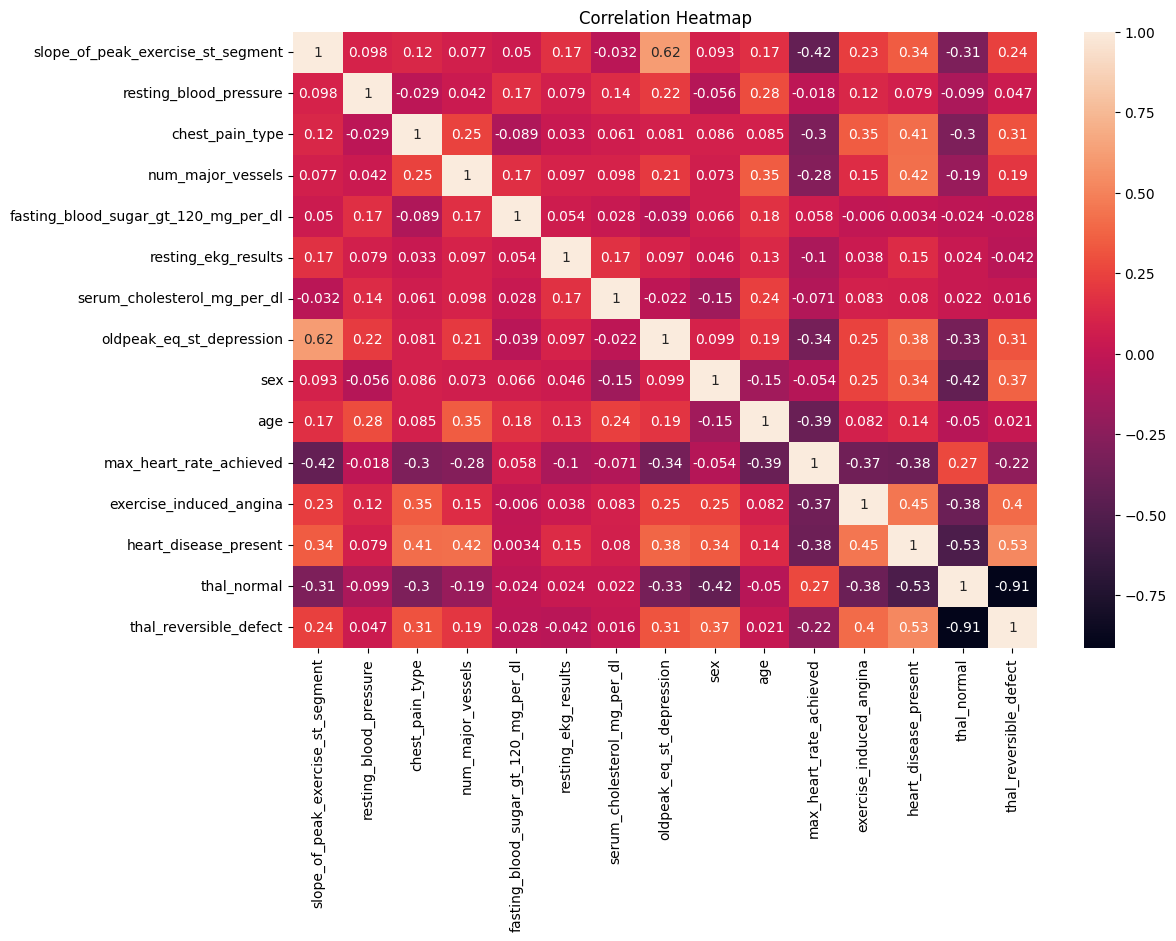

In [34]:
# correlation heatmap
plt.figure(figsize = (12,8))
sns.heatmap(df.corr(), annot = True)
plt.title("Correlation Heatmap")
plt.show()

# Step 6 : Preprocessing

In [39]:
col_num = df.select_dtypes(include = ["int","float64"]).columns
col_num

Index(['slope_of_peak_exercise_st_segment', 'resting_blood_pressure',
       'chest_pain_type', 'num_major_vessels',
       'fasting_blood_sugar_gt_120_mg_per_dl', 'resting_ekg_results',
       'serum_cholesterol_mg_per_dl', 'oldpeak_eq_st_depression', 'sex', 'age',
       'max_heart_rate_achieved', 'exercise_induced_angina',
       'heart_disease_present'],
      dtype='object')

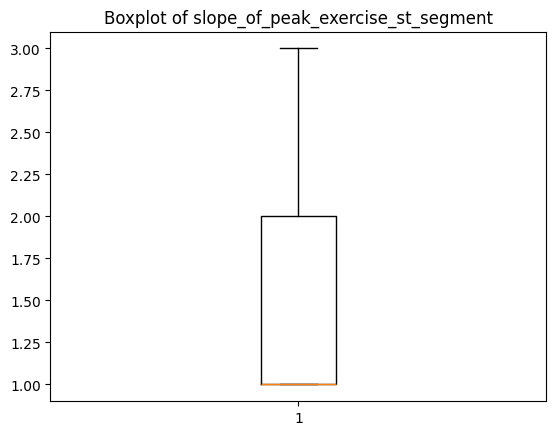

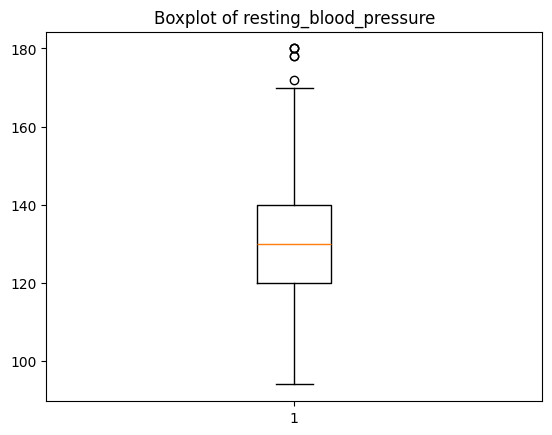

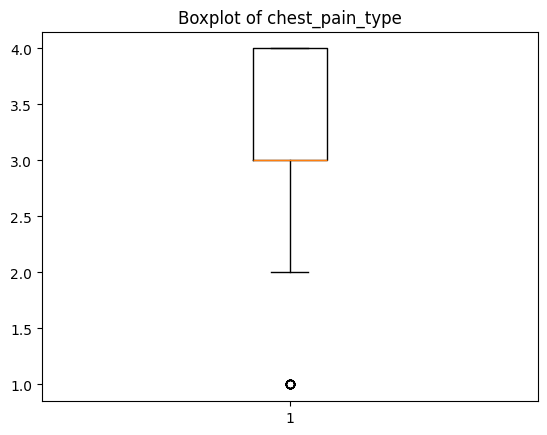

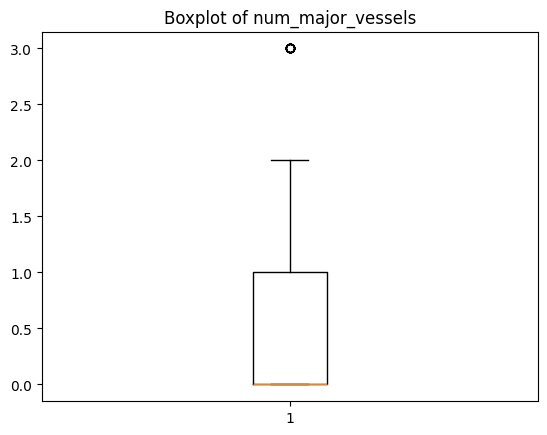

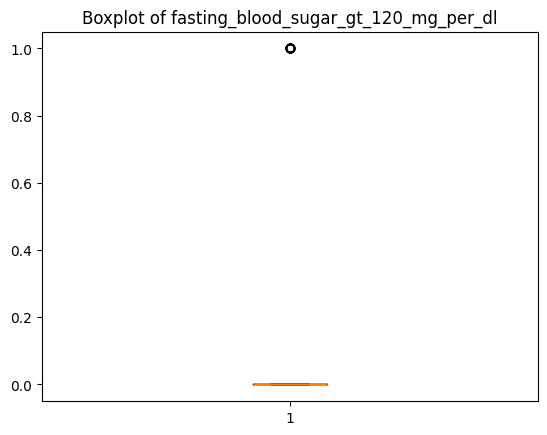

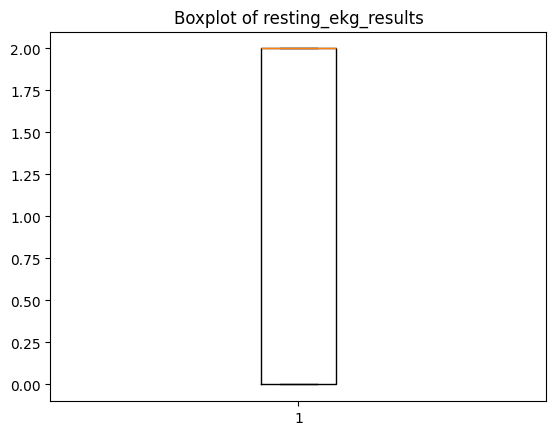

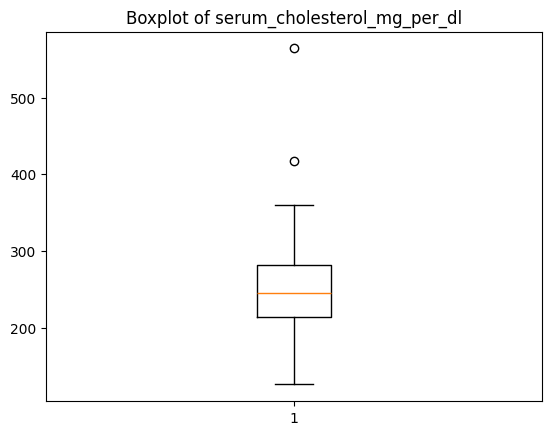

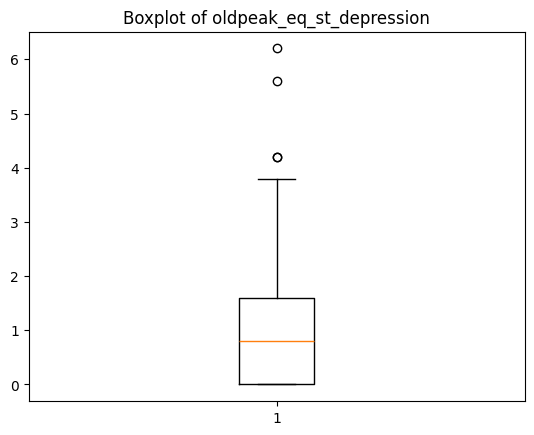

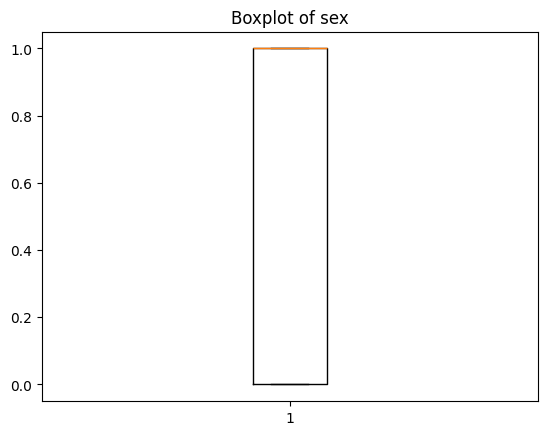

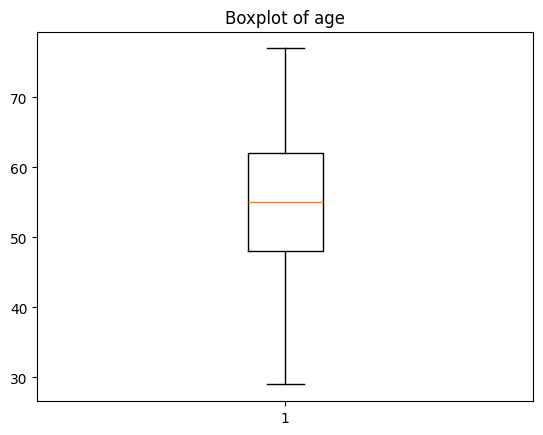

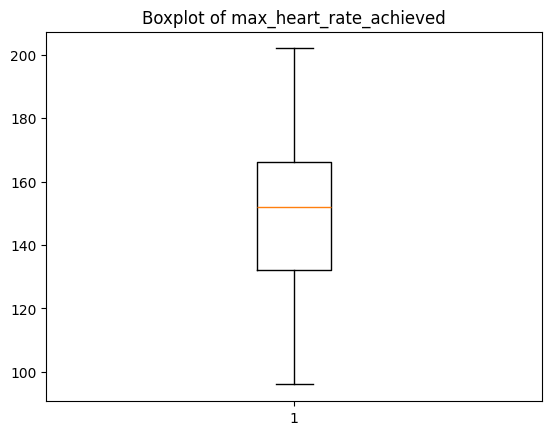

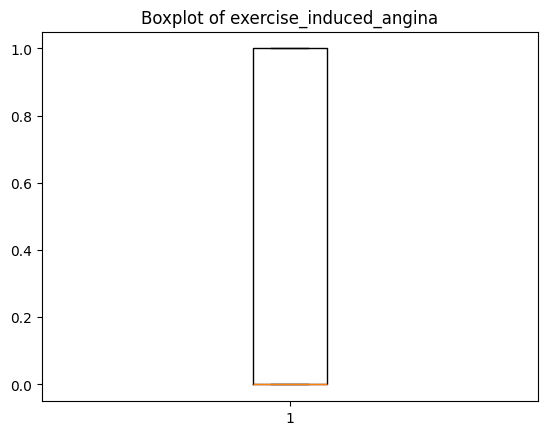

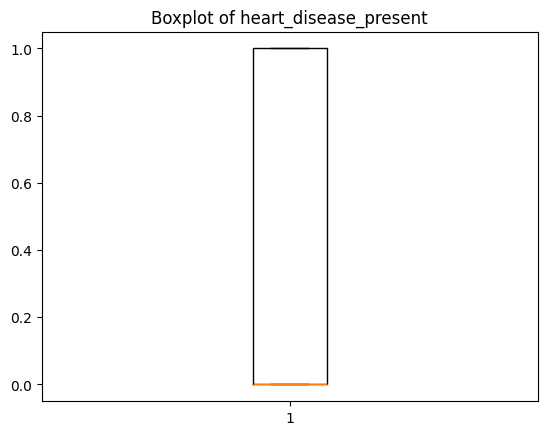

In [40]:
import matplotlib.pyplot as plt

for col in col_num:
  plt.figure()
  plt.boxplot(df[col])
  plt.title(f"Boxplot of {col}")
  plt.show()

“I analyzed outliers using the IQR method. Since the number of outliers was very small, I chose not to handle them to avoid losing important information, especially because in medical datasets extreme values can be meaningful.”

# Step 6 : Feature Engineering

In [41]:
df = pd.get_dummies(df, drop_first=True)

In [42]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180 entries, 0 to 179
Data columns (total 15 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   slope_of_peak_exercise_st_segment     180 non-null    int64  
 1   resting_blood_pressure                180 non-null    int64  
 2   chest_pain_type                       180 non-null    int64  
 3   num_major_vessels                     180 non-null    int64  
 4   fasting_blood_sugar_gt_120_mg_per_dl  180 non-null    int64  
 5   resting_ekg_results                   180 non-null    int64  
 6   serum_cholesterol_mg_per_dl           180 non-null    int64  
 7   oldpeak_eq_st_depression              180 non-null    float64
 8   sex                                   180 non-null    int64  
 9   age                                   180 non-null    int64  
 10  max_heart_rate_achieved               180 non-null    int64  
 11  exercise_induced_an

# Step 7 : Train_test split
splitting the data

In [44]:
x = df.drop("heart_disease_present" , axis = 1)
y = df["heart_disease_present"]
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size = 0.2,random_state = 42)

In [46]:
x_train.shape

(144, 14)

In [47]:
x_test.shape

(36, 14)

In [49]:
y_train.shape

(144,)

In [50]:
y_test.shape

(36,)

In [51]:
x.shape

(180, 14)

In [52]:
y.shape

(180,)

# Step 8: Feature Scaling


In [54]:
scaler = StandardScaler()

x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


# Step 9 : Logistic Regression_model 1

In [55]:
lr = LogisticRegression(max_iter = 1000)
lr.fit(x_train,y_train)
y_pred = lr.predict(x_test)

# Step 10 : Evaluation_metrics for model 1

In [56]:
print(accuracy_score(y_test,y_pred))
print(confusion_matrix(y_test,y_pred))
print(classification_report(y_test,y_pred))

0.5555555555555556
[[ 0 16]
 [ 0 20]]
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        16
           1       0.56      1.00      0.71        20

    accuracy                           0.56        36
   macro avg       0.28      0.50      0.36        36
weighted avg       0.31      0.56      0.40        36



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


# Step 11: Random Forest_model 2

In [60]:
rf = RandomForestClassifier(random_state = 42)
rf.fit(x_train,y_train)
y_pred_rf= rf.predict(x_test)

# Evaluation_metrics for model 2

In [61]:
print(accuracy_score(y_test,y_pred_rf))
print(confusion_matrix(y_test,y_pred_rf))
print(classification_report(y_test,y_pred_rf))

0.5555555555555556
[[ 0 16]
 [ 0 20]]
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        16
           1       0.56      1.00      0.71        20

    accuracy                           0.56        36
   macro avg       0.28      0.50      0.36        36
weighted avg       0.31      0.56      0.40        36



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


# Step 12 : Hyperparameter Tuning    
Hyperparameter Tuning using GridSearchCV

In [63]:
from sklearn.model_selection import GridSearchCV
param_grid = {
    'n_estimators': [100,200],
    'max_depth': [5,10,None],
    'min_samples_split': [2, 5]
}

grid = GridSearchCV(RandomForestClassifier(), param_grid , cv = 3)
grid.fit(x_train,y_train)

best_rf = grid.best_estimator_

print("best parameters:",grid.best_params_)

best parameters: {'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 100}


# Final Model Evaluation

In [65]:
y_pred_best = best_rf.predict(x_test)
print(accuracy_score(y_test,y_pred_best))
print(confusion_matrix(y_test,y_pred_best))
print(classification_report(y_test,y_pred_best))

0.7222222222222222
[[ 8  8]
 [ 2 18]]
              precision    recall  f1-score   support

           0       0.80      0.50      0.62        16
           1       0.69      0.90      0.78        20

    accuracy                           0.72        36
   macro avg       0.75      0.70      0.70        36
weighted avg       0.74      0.72      0.71        36



# Step 13 : ROC_AUC Curve

<function roc_auc_score at 0x7af53e9f31a0>


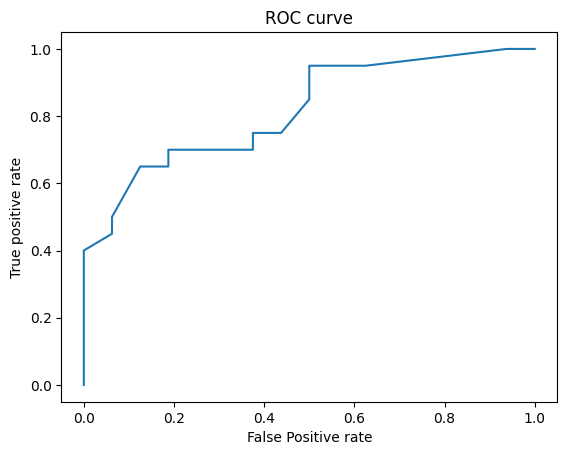

In [68]:
y_prob = best_rf.predict_proba(x_test)[:,1]

roc_score = roc_auc_score(y_test,y_prob)
print(roc_auc_score)
fpr , tpr, _ = roc_curve(y_test,y_prob)

plt.plot(fpr, tpr)
plt.xlabel("False Positive rate")
plt.ylabel("True positive rate")
plt.title("ROC curve")
plt.show()

# Step 14 : Feature Importance

In [71]:
importances = best_rf.feature_importances_
features = x.columns

feat_df = pd.DataFrame({"Features": features, "Importances": importances}).sort_values(by="Importances",ascending = False)
feat_df.head(10)

,Features,Importances
7,oldpeak_eq_st_depression,0.121874
10,max_heart_rate_achieved,0.107897
6,serum_cholesterol_mg_per_dl,0.098320
9,age,0.094495
2,chest_pain_type,0.092456
11,exercise_induced_angina,0.086494
12,thal_normal,0.086093
13,thal_reversible_defect,0.075254
3,num_major_vessels,0.067952
1,resting_blood_pressure,0.067877


# Conclusion :

- Built a classification model to predict heart disease
- Compared Logistic Regression and Random Forest
- Improved model using hyperparameter tuning
- Evaluated performance using multiple metrics

# Final Result:
Random Forest performed better due to handling complex relationships.

# Challenges Faced

- Identifying `thal` as a categorical feature despite numeric representation  
- Deciding whether to handle very few outliers (≤3 per column)  
- Avoiding reliance on accuracy as the only evaluation metric  
- Choosing the best model between Logistic Regression and Random Forest  
- Improving model performance beyond default parameters  
- Understanding feature importance and model interpretability  
- Deciding which columns to drop (e.g., `patient_id`)  
- Handling preprocessing steps correctly (encoding, scaling)


